# Seminar 6: Few/Zero Shot Learning


## Introduction
We are used to thinking that machine learning requires a large amount of data. But what if:

1. There are some rare cases, of which there are only a few examples in the training sample. Then, formally, we have a classification task for $C$ classes, of which $K < C$ classes have few training examples, and we need to be able to distinguish between all classes, both numerous and few.

2. For some tasks, it may be difficult (time-consuming, expensive, unreliable, etc.) to collect certain data (e.g., computed tomography or MRI). Here, we have only $K$ classes, and for each of these classes, there are few objects in the sample.

A number of Few Shot Learning algorithms have been developed for such tasks. If we have $K$ rare classes, each represented by $N$ objects, then in English-language literature such a Few Shot task is called $K$-way $N$-shot classification/regression/detection/...

Today we will look at solutions that allow us to obtain adequate prediction quality despite the extremely small (or even completely absent!) amount of data.

### Seminar plan:
0. Load data for Few Shot classification
1. Metric Learning for Few Shot classification
2. Meta Learning for Few Shot classification
3. Zero Shot classification

## 0. Let's load the data for Few Shot classification

In [1]:
!pip install pytorch-lightning -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 53.2 MB/s eta 0:00:00


In [2]:
!pip install higher -q

In [3]:
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple

import higher
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchmetrics.functional import accuracy
from torchmetrics.functional import accuracy as tm_accuracy
from torchvision import datasets, transforms

warnings.filterwarnings("ignore")
%matplotlib inline

First, let's gather a small sample. Let it be a subset of the well-known CIFAR10 sample, which contains 10 classes of 32x32 color images.

Let's create a `CifarSubset` class, which will be a dataset consisting of a subset of __N__ objects from each of the 10 classes.

In [4]:
class CifarSubset(torchvision.datasets.vision.VisionDataset):
    def __init__(self, root, k_n, train: bool, download: bool, transform):
        super().__init__(root, transform=transform, target_transform=None)

        self.k_n = k_n
        self.data = self.__sample_uniform_subset(root, train, download, transform)

    def __sample_uniform_subset(self, root, train, download, transform):
        """
        The method will return a subsample of the CIFAR10 sample such that
        there are exactly k_n objects in each class.

        :param: dataset — the original sample
        :param: k_n — the number of objects in each class
        """

        self.cifar_full = torchvision.datasets.CIFAR10(
            root=root, train=train, download=download, transform=transform
        )

        number_of_classes = len(self.cifar_full.classes)
        class_count = [0 for _ in range(number_of_classes)]
        subset = []

        for image, label in self.cifar_full:
            # we need exactly k_n objects for every class
            if class_count[label] < self.k_n:
                subset.append((image, label))
                class_count[label] += 1

            # if each class has k_n objects, exit the loop
            if sum(class_count) == number_of_classes * self.k_n:
                break
        return subset

    def __getitem__(self, index):
        return self.data[index][0], self.data[index][1]

    def __len__(self):
        return len(self.data)

In [5]:
N_SHOT = 5  # number of objects of each class in the training sample

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)

cifar_train_subset = CifarSubset(
    root="./cifar", k_n=N_SHOT, train=True, download=True, transform=transform
)

cifar_val_subset = CifarSubset(
    root="./cifar", k_n=N_SHOT, train=False, download=True, transform=transform
)

100%|██████████| 170M/170M [00:19<00:00, 8.65MB/s]


Many algorithms for Few Shot (and especially Meta) Learning are best trained using so-called __episodes__, where an episode is a situation that is as close as possible to the conditions of inference. For example, if during inference we ask the model to classify N objects of each of K classes, then it should be trained in batches of N * K classes.

And since in our case N * K is all of our data, one episode is equivalent to one epoch.

In [6]:
# Since we need to learn in episodes, the batch must contain all the data at once.
train_dataloader = torch.utils.data.DataLoader(
    cifar_train_subset,
    batch_size=N_SHOT * 10,  # 10 because 10 classes
    shuffle=True,
    num_workers=1,
)
val_dataloader = torch.utils.data.DataLoader(
    cifar_val_subset, batch_size=N_SHOT * 10, shuffle=True, num_workers=1
)

If we use the solutions we had until today, the model simply will not learn any patterns of a small class and will be severely overfit.

A number of algorithms have been developed specifically for such tasks — we will look at several of them today!

---

## 1. Few Shot learning

The main goal of this type of approach is to understand what the learned features (or embeddings) of a typical representative of each class look like. With such class “prototypes,” it will be possible to compare the features of each object with the features of each prototype and select the one that is most similar to our object. For this to work, we need to make sure that during training, similar objects are located close to each other in the feature space, while dissimilar objects are far apart (just like in a clustering task).

---

At a high level, it always looks roughly the same:

1. A model is trained on the data we have, the output of which will be __class probabilities__, rather than a __multidimensional feature vector__ (we can take any of our previous classification/regression models and discard the last classification layer).

2. The loss function is selected so that the model learns to group similar data together.

3. In the case of __K__-way __N__-shot classification, the same thing happens during both training and inference. A certain percentage of __N__ objects from each class is selected to form a class prototype by averaging their features. This subsample is called the support set. The remaining objects (which we will actually compare with this prototype) are called the query set.

---

1. Построим простую свёрточную архитектуру, выходом которой для каждого объекта будет многомерный вектор выученных признаков:

In [7]:
class PrototypeNet(nn.Module):
    def __init__(self, input_dim=3, hid_dim=64, output_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            self.__conv_block(input_dim, hid_dim),
            self.__conv_block(hid_dim, hid_dim),
            self.__conv_block(hid_dim, hid_dim),
            self.__conv_block(hid_dim, output_dim),
        )

    def __conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        x = self.encoder(x)
        return x.view(x.size(0), -1)

2. Now we need to choose a loss function that will penalize:

- large distances between an object and its class prototype
- small distances between an object and a prototype that is not its class

  Since there are no ready-made solutions in Torch, we will have to write our own Loss... To avoid having to come up with the mathematics describing the conditions we need, we will use the approach presented in [this work](https://arxiv.org/pdf/1703.05175.pdf). Then the formation of the error function will look like this:

---

- For each class $c$:
- For each object $q$ from our __query_set($c$)__

$$
  Loss +=  {1 \over N_c * N_q} * \left[\text{dist}(\text{emb}(q), p_c) + \log{\sum_{classes} e^{-\text{dist}(\text{emb}(q), p_{class})}} \right],
  $$

where $\text{emb}(q)$ is the embedding obtained after object $q$ passed through our convolutional network, and $\text{dist}(\text{emb}(q), p_c)$ is some distance function between this embedding and the prototype $p_c$ of class $c$.

---


  At first glance, something terrible is happening, and it is unclear why these particular values were chosen. But if you look closely, you will see that the first term in parentheses is simply the distance from our object to the prototype of its class, and the second term (in the form of a sum) becomes smaller the further our object is from all other prototypes.
  
  Thus, by minimizing the presented functionality according to the parameters of the neural network, we bring our object closer to its prototype and further away from all others.

In [8]:
class PrototypeLoss(nn.Module):
    def __init__(self, n_shot: int):
        super().__init__()
        self.n_shot = n_shot
        self.__prototypes: list = None

    def __distance(self, inp, other):
        return torch.linalg.norm(inp - other)  # Euclidean distance between two vectors.

    def __prototype_loss(
        self,
        predicted_embeddings: torch.Tensor,
        target_labels: torch.Tensor,
        support_percent: float = 0.6,
    ):
        """
        :param predicted_embeddings: feature vectors obtained as a result of the model's operation; shape = (N, emb_size)
        :param target_labels: list of target classes; shape=(N)
        :param: support_percent: percentage of data from each class that will be used to form the class prototype
        """

        assert 0 < support_percent < 1

        classes = torch.unique(target_labels)
        n_classes = len(classes)  # classes per episode

        # amount of data required to determine the class prototype
        n_support = int(self.n_shot * support_percent)
        # amount of data to compare with the class prototype
        n_query = self.n_shot - n_support

        prototypes = []  # class prototypes (number of classes, feature vector)
        class_queries = []

        for c in classes:
            supports = predicted_embeddings[target_labels == c][:n_support]
            queries = predicted_embeddings[target_labels == c][n_support:]

            # A class prototype is the average value of all support objects.
            prototypes.append(supports.mean(0))
            # class query are all objects that did not make it into support
            class_queries.append(queries)

        loss = torch.tensor(0.0)

        for i, queries in enumerate(class_queries):
            for query in queries:  # all objects of the i class
                loss += self.__distance(prototypes[i], query)

                distances = torch.stack(
                    [
                        self.__distance(query, p)
                        for ci, p in enumerate(prototypes)
                        if i != ci
                    ]
                )
                # add a value that's the opposite of the sum of these distances
                # the greater the distance, the less we penalize the model

                loss += torch.log(torch.sum(torch.exp(-distances)))

        # save prototypes for future use
        self.prototypes = torch.stack(prototypes)

        return loss / (n_classes * n_query)

    def forward(self, predicted_embeddings, targets) -> torch.Tensor:
        return self.__prototype_loss(predicted_embeddings, targets)

    def get_class_prototypes(self) -> list:
        return self.__prototypes

In [9]:
class FewShotMetricLearner(pl.LightningModule):
    def __init__(self, n_shot: int) -> None:
        super().__init__()

        self.model = PrototypeNet()
        self.loss = PrototypeLoss(n_shot)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-2)
        # for later
        self.prototypes = None

    def forward(self, x) -> torch.Tensor:
        return self.model(x)

    def configure_optimizers(self):
        return self.optimizer

    def predict_labels(self, batch_embeddings):
        if self.prototypes == None:
            raise ValueError("self.prototypes was not set")

        ans = []
        for e in batch_embeddings:
            dists = torch.linalg.norm(self.prototypes - e, dim=1)
            ans.append(torch.argmin(dists))

        return torch.stack(ans)

    def training_step(self, train_batch, batch_idx) -> torch.Tensor:
        images, target = train_batch
        embeddings = self.forward(images)

        loss = self.loss(embeddings, target)
        # label_predictions = self.predict_labels(embeddings)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, val_batch, batch_idx) -> None:
        images, target = val_batch
        embeddings = self.forward(images)

        loss = self.loss(embeddings, target)
        self.prototypes = self.loss.prototypes

        label_predictions = self.predict_labels(embeddings)
        acc = accuracy(label_predictions, target, task="multiclass", num_classes=10)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

In [10]:
few_shot_metric_learner = FewShotMetricLearner(n_shot=N_SHOT)

trainer = pl.Trainer(accelerator="cpu", max_epochs=50)
trainer.fit(few_shot_metric_learner, train_dataloader, val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ PrototypeNet  │  113 K │ train │     0 │
│ 1 │ loss  │ PrototypeLoss │      0 │ train │     0 │
└───┴───────┴───────────────┴────────┴───────┴───────┘

Trainable params: 113 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 113 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


In [11]:
len(cifar_train_subset)

50

In [12]:
len(cifar_val_subset)

50

We classify objects with an accuracy of 0.6-0.7, having trained (in about a minute on the CPU) the simplest convolutional network on only 5 objects (!!!) of each class.

---

## 2. Few Shot Meta Learning
    
Meta learning sets itself the task of “learning to learn.” In our case, “learning to classify.” This is a more general task, because in the case of learning with a teacher, we don't just “learn to classify,” but “learn to classify into specific classes.” Let's take a closer look at one of the Meta Learning algorithms.

__Model Agnostic Meta Learning (MAML)__ [link to article](https://arxiv.org/pdf/1703.03400.pdf)

The goal of Few Shot meta learning is to train a model that can quickly adapt to a new task using only a few objects and training iterations. Essentially, the __meta learning__ problem treats __entire tasks as training examples__. That is, the entire task of classifying cats and dogs is one training sample object, classifying cars and airplanes is a second training sample object, and so on.

1. When solving a K-way N-shot classification episode, we show different K classes in each episode!
2. During the episode, we use the train sample to train the classifier (any architecture we are familiar with, hence the Model Agnostic in the name) as we did in a regular classification task.
3. After the episode, we use the error and loss on the _val_ sample (where we already have a different set of classification tasks) to perform meta-learning.
4. At the end of training, we use the _test_ sample, consisting of several classification tasks (not shown in either val or test), on which the quality is measured.

![a](https://uvadlc-notebooks.readthedocs.io/en/latest/_images/few-shot-classification.png)

This is how generalization is achieved. The model learns not only to distinguish between __K__ classes, but also to distinguish between __any K classes__ based on __N__ examples. The meta-learning process finds and adapts the most task-sensitive parameters of the model. It is worth noting that this is just one representative of a huge set of Meta Learning algorithms.

P.S. There is a library called [pytorch-meta](https://github.com/tristandeleu/pytorch-meta) (this is not an official implementation from the pytorch team, but it has useful functionality), which contains implementations of well-known meta learning algorithms, including [the implementation of the MAML algorithm](https://github.com/tristandeleu/pytorch-meta/tree/master/examples/maml), which we discussed above.

---

### MAML for MNIST

We will use the [`higher`](https://github.com/facebookresearch/higher) library to implement the **inner loop** in meta-learning tasks.
Regular PyTorch optimizers do not allow differentiation throughout the training process, so `higher` solves this problem.

* Allows you to create **temporary copies of the model** with separate parameters (`fmodel`) without affecting the original.
* Supports **backpropagation through training steps**, which is necessary for MAML and similar methods.
* Provides an `innerloop_ctx` interface that allows you to use familiar PyTorch code (forward, backward, step) while preserving the computational graph.

1. The original model is passed to `higher.innerloop_ctx` along with the inner optimizer.
2. An adaptable copy of the model (`fmodel`) and an optimizer wrapper (`diffopt`) are created inside the context.
3. During several adaptation steps, the parameters of `fmodel` are updated based on support examples.
4. After that, the meta-loss is calculated on query examples, which is used to update the original model.

Thus, `higher` allows you to organize **gradient adaptation within the training loop** without breaking the computation graph or manually duplicating the training code.
This approach is standard for implementing the **MAML (Model-Agnostic Meta-Learning)** algorithm and its variations.

Using @dataclass provides a convenient and readable way to store all hyperparameters in one place.

Main parameters

**device** — automatic selection between cuda and cpu to accelerate calculations when a GPU is available.

**n_way** = 5 — number of classes in each task (N-way), typical for few-shot experiments.

**k_shot** = 5 — number of training examples per class (K-shot), i.e., 5 images per class.

**q_query** = 5 — number of test (query) examples per class, used to evaluate the quality of adaptation.

**inner_steps** = 1 — number of internal gradient update steps. In practice, meta-learning often uses 1–5 steps to balance learning speed and stability.

**inner_lr** = 0.4 — learning rate of the internal optimizer. A relatively high learning rate accelerates adaptation in a small number of steps.

**meta_lr** = 1e-3 — learning rate of the meta-optimizer (e.g., Adam) that controls the update of the “basic” model parameters.

**meta_batch** = 4 — number of tasks (episodes) processed in a single meta-iteration.

**meta_iters** = 400 — the number of meta-training iterations. The value 400 was chosen for illustrative experiments; for stable quality, 5000–10000 iterations are recommended.


In [13]:
@dataclass
class Cfg:
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    n_way: int = 5
    k_shot: int = 5
    q_query: int = 5
    inner_steps: int = 1  # change from 1 to 5
    inner_lr: float = 0.4
    meta_lr: float = 1e-3
    meta_batch: int = 4
    meta_iters: int = 400  # 5k-10k will be better
    data_root: str = "./data"


cfg = Cfg()

A compact convolutional neural network ConvNetMNIST has been implemented for few-shot learning tasks on images from the MNIST dataset (input size — 1×28×28).

The architecture follows the principles typical of meta-learning: simple, stable, and expressive enough to quickly adapt to new classes.

In [14]:
class ConvNetMNIST(nn.Module):
    def __init__(self, out_dim: int):
        super().__init__()

        def block(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, padding=1, bias=False),
                nn.GroupNorm(1, co),  # BatchNorm but better
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.enc = nn.Sequential(
            block(1, 64),  # 28 -> 14
            block(64, 64),  # 14 -> 7
            block(64, 64),  # 7  -> 3
            block(64, 64),  # 3  -> 1
        )
        self.head = nn.Linear(64, out_dim)

    def forward(self, x):
        f = self.enc(x)  # [B,64,1,1]
        f = f.view(x.size(0), -1)  # [B,64]
        return self.head(f)  # [B,out_dim]

Функция build_class_index предназначена для создания структуры данных, удобной для выборки примеров по классам.

**Алгоритм работы:**


1.   Выполняется проход по всему датасету.
2.   Для каждого элемента извлекается метка класса y.
3.   Индекс примера добавляется в словарь by_class, где ключ — это класс, а значение — список индексов всех соответствующих ему примеров.
4.   Если класс встречается впервые, для него создаётся новый список.

В результате формируется словарь вида:

```
{
  class_0: [idx0, idx1, ...],
  class_1: [idx2, idx3, ...],
  ...
}
```

**sample_episode**(dataset, by_class, classes_pool, n_way, k_shot, q_query, rng)

Функция формирует один эпизод few-shot обучения в формате N-way K-shot.
Пошаговая логика:

1.  Из пула доступных классов случайным образом выбираются n_way классов.

2.  Для каждого выбранного класса случайным образом отбирается k_shot + q_query индексов.



*   Первые k_shot используются как обучающие (support) примеры.
*   Последующие q_query — как тестовые (query) примеры.



3.  Метки классов перенумеровываются локально (от 0 до n_way-1), чтобы не зависеть от глобальной нумерации датасета.

4.  Из выбранных индексов извлекаются изображения, которые объединяются в тензоры:

* Xs, Ys — support-примеры и их метки;

* Xq, Yq — query-примеры и их метки.

5.  Все изображения укладываются в батчи с помощью torch.stack.

Таким образом, каждая выборка sample_episode создаёт самостоятельную мини-задачу классификации, которая используется для мета-обучения моделей few-shot.

In [15]:
def build_class_index(dataset) -> Dict[int, List[int]]:
    byc: Dict[int, List[int]] = {}
    for i in range(len(dataset)):
        _, y = dataset[i]
        y = int(y)
        byc.setdefault(y, []).append(i)
    return byc


def sample_episode(
    dataset,
    by_class: Dict[int, List[int]],
    classes_pool: List[int],
    n_way,
    k_shot,
    q_query,
    rng: random.Random,
):
    classes = rng.sample(classes_pool, n_way)
    xs, ys, xq, yq = [], [], [], []
    for new_y, cls in enumerate(classes):
        pool = by_class[cls]
        idxs = rng.sample(pool, k_shot + q_query)
        s_idx, q_idx = idxs[:k_shot], idxs[k_shot:]
        for i in s_idx:
            x, _ = dataset[i]
            xs.append(x)
            ys.append(new_y)
        for i in q_idx:
            x, _ = dataset[i]
            xq.append(x)
            yq.append(new_y)
    Xs = torch.stack(xs, 0)
    Ys = torch.tensor(ys, dtype=torch.long)
    Xq = torch.stack(xq, 0)
    Yq = torch.tensor(yq, dtype=torch.long)
    return Xs, Ys, Xq, Yq

Загрузка нашего MNIST датасета для Few-short.

In [16]:
def load_mnist():
    tfm = transforms.Compose(
        [
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
        ]
    )
    train_ds = datasets.MNIST(cfg.data_root, train=True, download=True, transform=tfm)
    test_ds = datasets.MNIST(cfg.data_root, train=False, download=True, transform=tfm)

    # meta-train классы: 0-4, meta-test классы: 5-9 (полностью раздельные)
    train_classes = [0, 1, 2, 3, 4]
    test_classes = [5, 6, 7, 8, 9]

    train_byc = build_class_index(train_ds)
    test_byc = build_class_index(test_ds)
    return train_ds, test_ds, train_byc, test_byc, train_classes, test_classes

The `meta_train` function implements the meta-training process of the model in the **episodic few-shot learning** paradigm using **gradient adaptation in the inner loop** and **meta-parameter updates in the outer loop**.

1. **Preparation for training**

   * The model is transferred to the selected device (`cuda` or `cpu`).
   * The Adam optimizer is initialized to update the meta-parameters.
   * A random number generator is set for reproducibility.
   * The model is put into training mode.

2. ** Outer loop (meta-iterations)**
   The loop is executed `cfg.meta_iters` times.
   At each iteration:

   * The meta-optimizer gradients are reset to zero.
   * The meta-loss accumulator `meta_loss` is initialized.

3. **Forming a batch of episodes**
   For each iteration of the outer loop, `cfg.meta_batch` independent episodes are formed using `sample_episode`.
   Each episode contains:

   * Support examples (`Xs`, `Ys`)
   * Query examples (`Xq`, `Yq`)
     The data is transferred to the training device.

4. **Inner loop**

   * A temporary SGD optimizer is initialized for fast parameter adaptation.
   * The `higher` library is used to create the `innerloop_ctx` context, which allows differentiation through adaptation.
   * During `cfg.inner_steps` steps:

     * The loss function is calculated based on support examples.
     * The parameters of the temporary model (`fmodel`) are updated by a gradient step.

5. **Evaluation on query examples**
   After adaptation, the loss function is calculated on `Xq`, `Yq`.
   Losses are accumulated in `meta_loss` for all episodes.

6. **Meta-parameter update (outer loop)**

   * The average value of `meta_loss` across a batch of episodes is used to calculate gradients.
   * The parameters of the initial model are updated using the Adam step.

7. **Logging**
   Every 100 iterations, the current value of meta-loss is output to track training progress.

As a result of executing the function:

* The model is trained **not for a specific task**, but **for the ability to quickly adapt** to new tasks based on a few examples (few-shot).
* The outer loop is responsible for updating the meta-parameters,
  while the inner loop is responsible for quick adaptation to each task.


In [17]:
def meta_train(model, train_ds, train_byc, train_classes):
    model.to(cfg.device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.meta_lr)
    rng = random.Random(0)
    model.train()

    for it in range(1, cfg.meta_iters + 1):
        opt.zero_grad()
        meta_loss = 0.0
        for _ in range(cfg.meta_batch):
            Xs, Ys, Xq, Yq = sample_episode(
                train_ds,
                train_byc,
                train_classes,
                cfg.n_way,
                cfg.k_shot,
                cfg.q_query,
                rng,
            )
            Xs, Ys, Xq, Yq = (
                Xs.to(cfg.device),
                Ys.to(cfg.device),
                Xq.to(cfg.device),
                Yq.to(cfg.device),
            )

            # inner-loop higher
            inner_opt = torch.optim.SGD(model.parameters(), lr=cfg.inner_lr)
            with higher.innerloop_ctx(model, inner_opt, copy_initial_weights=False) as (
                fmodel,
                diffopt,
            ):
                for _ in range(cfg.inner_steps):
                    logits_s = fmodel(Xs)
                    loss_s = F.cross_entropy(logits_s, Ys)
                    diffopt.step(loss_s)

                logits_q = fmodel(Xq)
                loss_q = F.cross_entropy(logits_q, Yq)

            meta_loss = meta_loss + loss_q

        meta_loss = meta_loss / cfg.meta_batch
        meta_loss.backward()
        opt.step()

        if it % 100 == 0:
            print(
                f"[meta-train] iter {it}/{cfg.meta_iters}  meta_loss={meta_loss.item():.4f}"
            )

    return model

Implementation of an external cycle for prediction and accuracy verification on new data.

In this code, we perform two tests: one on a model without adaptation to the new task (acc_before_adaptation) and one with adaptation (demo_meta_test).

In [18]:
@torch.no_grad()
def acc_before_adaptation(model, Xq, Yq) -> float:
    model.eval()
    logits = model(Xq)
    preds = logits.argmax(dim=-1)
    return (preds == Yq).float().mean().item()


def acc_after_adaptation(model, Xs, Ys, Xq, Yq, inner_steps, inner_lr) -> float:
    # we need enable_grad for adaptation
    with torch.enable_grad():
        inner_opt = torch.optim.SGD(model.parameters(), lr=inner_lr)
        with higher.innerloop_ctx(model, inner_opt, copy_initial_weights=False) as (
            fmodel,
            diffopt,
        ):
            fmodel.train()
            for _ in range(inner_steps):
                logits_s = fmodel(Xs)
                loss_s = F.cross_entropy(logits_s, Ys)
                diffopt.step(loss_s)
            fmodel.eval()
            logits_q = fmodel(Xq)
            preds = logits_q.argmax(dim=-1)
            return (preds == Yq).float().mean().item()


def demo_meta_test(model, test_ds, test_byc, test_classes, seed=123):
    rng = random.Random(seed)
    #  1 episode from NEW classes(5–9)
    Xs, Ys, Xq, Yq = sample_episode(
        test_ds, test_byc, test_classes, cfg.n_way, cfg.k_shot, cfg.q_query, rng
    )
    Xs, Ys, Xq, Yq = (
        Xs.to(cfg.device),
        Ys.to(cfg.device),
        Xq.to(cfg.device),
        Yq.to(cfg.device),
    )

    before = acc_before_adaptation(model, Xq, Yq)
    after = acc_after_adaptation(model, Xs, Ys, Xq, Yq, cfg.inner_steps, cfg.inner_lr)

    print(
        f"\n[meta-test @ MNIST, classes 5–9] {cfg.n_way}-way {cfg.k_shot}-shot {cfg.q_query}-query"
    )
    print(f"Accuracy BEFORE adaptation: {before:.3f}")
    print(f"Accuracy AFTER  adaptation: {after:.3f}")
    return before, after

In [19]:
torch.manual_seed(0)
random.seed(0)

train_ds, test_ds, train_byc, test_byc, train_classes, test_classes = load_mnist()

# n_way (local labels within an episode)
model = ConvNetMNIST(out_dim=cfg.n_way)

# 1) Meta learning on 0-4
model = meta_train(model, train_ds, train_byc, train_classes)

# 2) Meta-test: NEW task: numbers 5–9
demo_meta_test(model, test_ds, test_byc, test_classes, seed=42)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.53MB/s]


[meta-train] iter 100/400  meta_loss=0.8825
[meta-train] iter 200/400  meta_loss=0.1138
[meta-train] iter 300/400  meta_loss=0.0627
[meta-train] iter 400/400  meta_loss=0.0539

[meta-test @ MNIST, classes 5–9] 5-way 5-shot 5-query
Accuracy BEFORE adaptation: 0.000
Accuracy AFTER  adaptation: 0.440


(0.0, 0.4399999976158142)

With adaptation (minimum number of GD epochs and large lr trained on a new task with small data), more than 0.6 in accuracy.

In [20]:
del cfg  # otherwise CLIP errors out

## 3. Zero Shot Learning

### Main idea:

In the __Zero-Shot__ classification/detection/segmentation task, we want to predict classes/boxes/masks of objects that we have never encountered during training. For example, we trained the model on cats and dogs, but it can also classify lions. Zero-shot models are trained on one set of data and tested on data that was not shown during training.

**Why do we need zero-shot?**
It may be that labeling is an unforgivably long and expensive operation. The design of zero-shot models allows us to use knowledge from one area (for example, from texts) to be able to predict classes in an image that were not seen during training.

We will learn about zero-shot models using the example of the well-known CLIP (Contrastive Language–Image Pre-training) architecture. Next in the seminar is a brief summary of an [article](https://openai.com/blog/clip/) from the blog of the company that created the architecture.

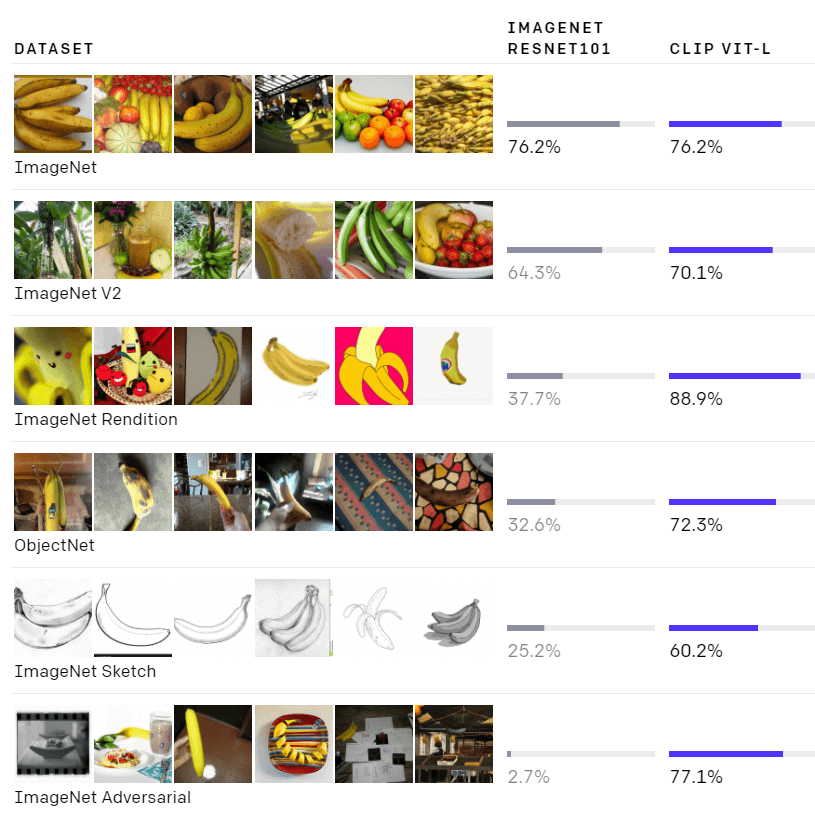

The data consists of images from the internet with captions. That is, one object in the training sample is a pair (image, text description). For example, a photo of a dog and the caption “This is my dog.” The training process consists of the following steps:

__1. Contrastive pre-training__

- There are two models: one for extracting features from images, and the other for extracting features from text. You can imagine any convolutional architecture without the last layer. The image below shows the Image Encoder and Text Encoder, respectively.

- Next, we train such a loss that the distance between the extracted image features and the extracted text features is small for the corresponding pair (image, text description) and large for all others.

  That is, the feature vector extracted from the image of a dog should be similar to the feature vector extracted from the text “This is my dog” and very different from the feature vector from the caption of another photo.

- In this way, the model learns to determine how relevant an image is to the text and vice versa.

__(2) and (3).  Create dataset classifier from label text__

When we need to classify a new image during testing, we compare the features extracted from that image with the features extracted from __N__ texts that we have specially prepared in advance. __N__ is the total number of classes, which includes both classes that were present during training and classes that were not. The special preparation of texts consists in the fact that these texts are formed according to a template of the format “This is a photo of {class}”, and then the name of the class is simply inserted for each of the __N__ classes. Because the model can compare features extracted from photo captions with features extracted from the photos themselves, during testing we can simply compare the similarity of the image features with the features of all artificially generated texts and classify the image by selecting the caption that the model considers most appropriate.

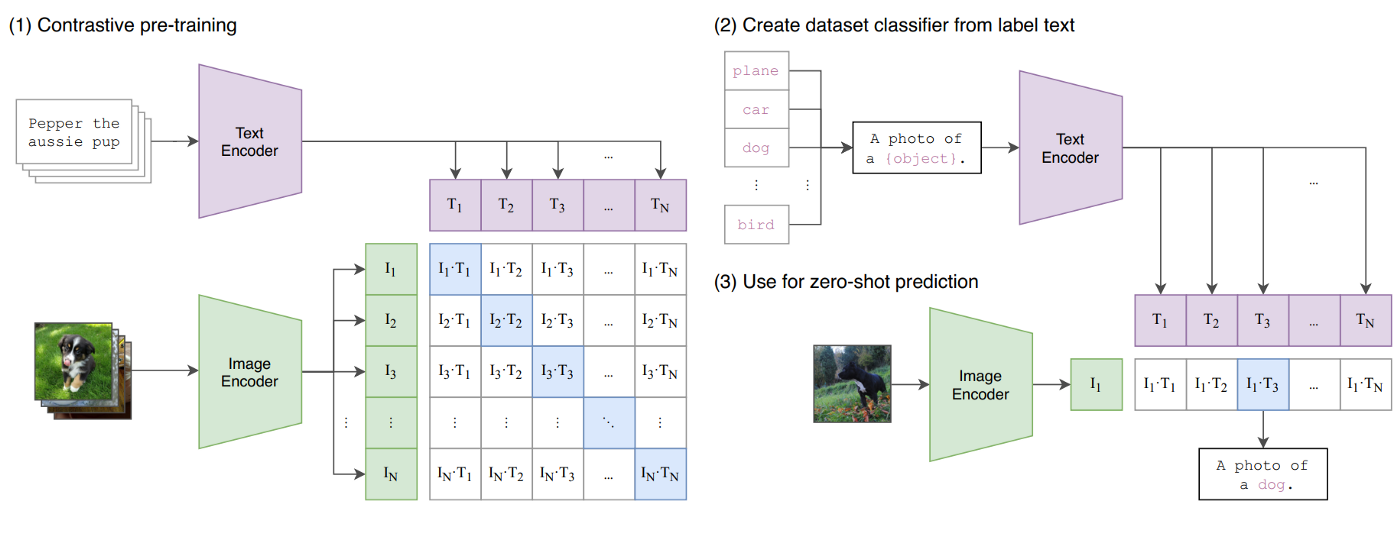

### Limitations:
1. It does not count the number of objects well and also confuses numbers, for example, on MNIST.
2. If you go deeper into the class (dog breed or car brand), the error increases significantly.

### Let's try!

In [21]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00


In [22]:
import numpy as np
import torch

print("Torch version:", torch.__version__)

Torch version: 2.9.0+cu126


To extract features from an image, the article lists several architectures on which experiments with the model were conducted. Here they are, from left to right (ViT stands for Visual Transformer; they will be discussed a little later (or much later)):

In [23]:
import clip

clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

We will use ResNet50.

In [ ]:
# if it fails due to a checksum mismatch, try running the cell again
model, preprocess = clip.load("RN50x64")
model.cuda().eval()
input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size

print(
    "Model parameters:",
    f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}",
)
print("Input resolution:", input_resolution)
print("Context length:", context_length)
print("Vocab size:", vocab_size)

  0%|                                     | 3.19M/1.26G [00:02<05:19, 4.22MiB/s]

Вспоминаем из предыдущего модуля, что прежде чем работать с текстом, его надо токенизировать.

In [ ]:
clip.tokenize("Hello World!")  # "Hello World!" -> "<BOS>Hello World!<EOS>"

In [ ]:
# embeddings size is 77
clip.tokenize("Hello World!").size()

Let's see how well the model understands sentences that are different in spelling but similar in meaning.

In [ ]:
tensor1 = clip.tokenize("google cloud platform").to(torch.float32)
tensor2 = clip.tokenize("amazon web services").to(torch.float32)

In [ ]:
cos = torch.nn.CosineSimilarity(dim=1)
output = cos(tensor1, tensor2)
print(output)

# It's the same

### Let's play a bit

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import skimage
import torch
from PIL import Image

os.makedirs(skimage.data_dir, exist_ok=True)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# filename and it's description
descriptions = {
    "page": "a page of text about segmentation",
    "chelsea": "a facial photo of a tabby cat",
    "astronaut": "a portrait of an astronaut with the American flag",
    "rocket": "a rocket standing on a launchpad",
    "camera": "a person looking at a camera on a tripod",
    "horse": "a black-and-white silhouette of a horse",
    "coffee": "a cup of coffee on a saucer",
    "moon": "surface of the moon",
}

In [ ]:
from PIL import Image
from skimage import data

builtin = {
    "page": Image.fromarray(data.page()),
    "chelsea": Image.fromarray(data.chelsea()),
    "astronaut": Image.fromarray(data.astronaut()),
    "rocket": Image.fromarray(data.rocket()),
    "camera": Image.fromarray(data.camera()),
    "horse": Image.fromarray(data.horse()),
    "coffee": Image.fromarray(data.coffee()),
    "moon": Image.fromarray(data.moon()),
}

original_images, images, texts = [], [], []
plt.figure(figsize=(16, 5))

for name, pil_im in builtin.items():
    if name not in descriptions:
        continue
    plt.subplot(2, 4, len(images) + 1)
    plt.imshow(pil_im)
    plt.title(f"{name}\n{descriptions[name]}")
    plt.xticks([])
    plt.yticks([])

    original_images.append(pil_im)
    images.append(preprocess(pil_im))  # CLIP-preprocess -> torch.Tensor CHW
    texts.append(descriptions[name])

plt.tight_layout()

### Pre-processing



In [ ]:
image_input = torch.tensor(np.stack(images)).cuda()


# We add "this is" — prompting 101 :)
text_tokens = clip.tokenize(["This is " + desc for desc in texts]).cuda()

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input).float()
    text_features = model.encode_text(text_tokens).float()

### Cosine similarity

In [ ]:
image_features /= image_features.norm(dim=-1, keepdim=True)  # normalize
text_features /= text_features.norm(dim=-1, keepdim=True)  # normalize
similarity = text_features.cpu().numpy() @ image_features.cpu().numpy().T

In [ ]:
count = len(descriptions)

plt.figure(figsize=(20, 14))
plt.imshow(similarity, vmin=0.1, vmax=0.3)
# plt.colorbar()
plt.yticks(range(count), texts, fontsize=18)
plt.xticks([])
for i, image in enumerate(original_images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")
for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[y, x]:.2f}", ha="center", va="center", size=12)

for side in ["left", "top", "right", "bottom"]:
    plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, count - 0.5])
plt.ylim([count + 0.5, -2])

plt.title("Cosine similarity between text and image features", size=20)

### Zero-shot classification

In [ ]:
from torchvision.datasets import CIFAR100

cifar100 = CIFAR100(os.path.expanduser("~/.cache"), transform=preprocess, download=True)

Now, for each of the CIFAR100 classes, we will create artificial captions using the template “This is a photo of a {class name}”. This will give us 100 captions, which we will use to compare the incoming image.

In [ ]:
text_descriptions = [f"This is a photo of a {label}" for label in cifar100.classes]
text_tokens = clip.tokenize(text_descriptions).cuda()

In [ ]:
with torch.no_grad():
    text_features = model.encode_text(text_tokens).float()
    text_features /= text_features.norm(dim=-1, keepdim=True)

text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
top_probs, top_labels = text_probs.cpu().topk(5, dim=-1)

In [ ]:
plt.figure(figsize=(16, 16))

for i, image in enumerate(original_images):
    plt.subplot(4, 4, 2 * i + 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(4, 4, 2 * i + 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs[i])
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.yticks(y, [cifar100.classes[index] for index in top_labels[i].numpy()])
    plt.xlabel("probability")

plt.subplots_adjust(wspace=0.5)
plt.show()